In [ ]:
import gymnasium as gym

# Create the CartPole environment
env = gym.make("CartPole-v1", render_mode="human")

# Reset the environment to get the initial observation
observation, info = env.reset()


Set up the Q-learning hyperparameters such as learning rate (alpha), discount factor (gamma), and exploration-exploitation rate (epsilon).


In [ ]:
alpha = 0.1  # Learning rate
gamma = 0.99  # Discount factor
epsilon = 1.0  # Initial exploration rate
min_epsilon = 0.01  # Minimum exploration rate
epsilon_decay_rate = 0.995  # Rate at which epsilon decays

print(f"Q-learning parameters initialized:\n  Alpha: {alpha}\n  Gamma: {gamma}\n  Epsilon (initial): {epsilon}\n  Min Epsilon: {min_epsilon}\n  Epsilon Decay Rate: {epsilon_decay_rate}")

Q-learning parameters initialized:
  Alpha: 0.1
  Gamma: 0.99
  Epsilon (initial): 1.0
  Min Epsilon: 0.01
  Epsilon Decay Rate: 0.995


## Discretize State Space

The CartPole environment has a continuous observation space. We need to discretize it into a finite number of bins for each observation component (cart position, cart velocity, pole angle, pole angular velocity) to create a Q-table.


In [ ]:
import numpy as np

# 1. Define the number of bins for each observation component
# Cart Position, Cart Velocity, Pole Angle, Pole Angular Velocity
num_bins = (
    10,  # Cart Position
    10,  # Cart Velocity
    10,  # Pole Angle
    10   # Pole Angular Velocity
)

# 2. Determine the minimum and maximum values for each observation component
# Using the previously created 'env' object from gymnasium
# If env is not defined, you might need to run `env = gym.make("CartPole-v1")` again.
lower_bounds = env.observation_space.low
upper_bounds = env.observation_space.high

# CartPole environment has some infinite bounds for velocity, so we need to clip them
upper_bounds[1] = 4.0   # Max cart velocity
lower_bounds[1] = -4.0  # Min cart velocity
upper_bounds[3] = 4.0   # Max pole angular velocity
lower_bounds[3] = -4.0  # Min pole angular velocity

print(f"Number of bins per component: {num_bins}")
print(f"Lower bounds of observation space: {lower_bounds}")
print(f"Upper bounds of observation space: {upper_bounds}")

# 3 & 4. Create a function to discretize the state
def discretize_state(observation, num_bins, lower_bounds, upper_bounds):
    discrete_state = []
    for i in range(len(observation)):
        # Ensure observation is within bounds (clipping)
        clipped_observation = np.clip(observation[i], lower_bounds[i], upper_bounds[i])

        # Calculate the size of each bin
        bin_width = (upper_bounds[i] - lower_bounds[i]) / num_bins[i]

        # Calculate the bin index
        bin_index = int((clipped_observation - lower_bounds[i]) / bin_width)

        # Ensure the index is within the valid range [0, num_bins[i]-1]
        discrete_state.append(min(bin_index, num_bins[i] - 1))

    return tuple(discrete_state)

# Test the function with a sample observation (e.g., the last observation from the previous run)
sample_observation = observation # 'observation' is available from previous cell's kernel state
discrete_sample = discretize_state(sample_observation, num_bins, lower_bounds, upper_bounds)
print(f"Sample continuous observation: {sample_observation}")
print(f"Corresponding discrete state: {discrete_sample}")

Number of bins per component: (10, 10, 10, 10)
Lower bounds of observation space: [-4.8        -4.         -0.41887903 -4.        ]
Upper bounds of observation space: [4.8        4.         0.41887903 4.        ]
Sample continuous observation: [-0.03495512 -0.01449558  0.01610315 -0.02338635]
Corresponding discrete state: (4, 4, 5, 4)


## Initialize Q-table
Create a multi-dimensional NumPy array (Q-table) to store the Q-values for each state-action pair, initialized with zeros or small random values.


---

In [ ]:
import numpy as np

# 1. Determine the total number of possible discrete states
total_discrete_states = 1
for bins in num_bins:
    total_discrete_states *= bins

# Or, more directly as a shape for the Q-table:
q_table_state_shape = num_bins

# 2. Get the number of possible actions from the environment's action space
num_actions = env.action_space.n

print(f"Total number of discrete states (shape): {q_table_state_shape}")
print(f"Number of actions: {num_actions}")

# 3. Initialize a NumPy array, named q_table, with dimensions corresponding
#    to the discrete state space and the action space, populated with zeros.
q_table = np.zeros(q_table_state_shape + (num_actions,))

print(f"Q-table initialized with shape: {q_table.shape}")

Total number of discrete states (shape): (10, 10, 10, 10)
Number of actions: 2
Q-table initialized with shape: (10, 10, 10, 10, 2)


## Implement Q-learning Training Loop
Develop the main Q-learning algorithm. This will involve iterating through a specified number of episodes, where in each episode the agent will choose actions using an epsilon-greedy policy, interact with the environment, and update the Q-table based on the Bellman equation.


In [ ]:
import gymnasium as gym

# Re-create the CartPole environment with render_mode=None for training
env = gym.make("CartPole-v1", render_mode=None)

num_episodes = 2000 # Define the total number of training episodes
rewards_per_episode = [] # Initialize an empty list to store rewards per episode

# Loop through each episode
for episode in range(num_episodes):
    # Reset the environment for a new episode
    observation, info = env.reset()
    # Discretize the initial observation to get the current state
    current_state = discretize_state(observation, num_bins, lower_bounds, upper_bounds)
    total_episode_reward = 0
    terminated = False
    truncated = False

    # Inner loop for a single episode (up to 200 timesteps or until termination)
    for timestep in range(200):
        # Epsilon-greedy policy for action selection
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Explore: choose a random action
        else:
            # Exploit: choose the action with the highest Q-value for the current state
            action = np.argmax(q_table[current_state])

        # Take the chosen action in the environment
        next_observation, reward, terminated, truncated, info = env.step(action)

        total_episode_reward += reward

        # Discretize the next observation to get the next state
        next_state = discretize_state(next_observation, num_bins, lower_bounds, upper_bounds)

        # Q-learning update rule
        # Q(s, a) = Q(s, a) + alpha * (reward + gamma * max(Q(next_state, a')) - Q(s, a))
        max_q_next_state = np.max(q_table[next_state])
        q_table[current_state + (action,)] = q_table[current_state + (action,)] + alpha * (
            reward + gamma * max_q_next_state - q_table[current_state + (action,)]
        )

        # Update current state for the next iteration
        current_state = next_state

        # Break if the episode is terminated or truncated
        if terminated or truncated:
            break

    # Append the total reward for the episode
    rewards_per_episode.append(total_episode_reward)

    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay_rate)

    # Print progress periodically
    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1}/{num_episodes}, Total Reward: {total_episode_reward}, Epsilon: {epsilon:.4f}")

print("Training complete.")
env.close() # Close the environment after training

Episode 100/2000, Total Reward: 59.0, Epsilon: 0.6058
Episode 200/2000, Total Reward: 43.0, Epsilon: 0.3670
Episode 300/2000, Total Reward: 161.0, Epsilon: 0.2223
Episode 400/2000, Total Reward: 86.0, Epsilon: 0.1347
Episode 500/2000, Total Reward: 77.0, Epsilon: 0.0816
Episode 600/2000, Total Reward: 148.0, Epsilon: 0.0494
Episode 700/2000, Total Reward: 200.0, Epsilon: 0.0299
Episode 800/2000, Total Reward: 88.0, Epsilon: 0.0181
Episode 900/2000, Total Reward: 144.0, Epsilon: 0.0110
Episode 1000/2000, Total Reward: 131.0, Epsilon: 0.0100
Episode 1100/2000, Total Reward: 58.0, Epsilon: 0.0100
Episode 1200/2000, Total Reward: 71.0, Epsilon: 0.0100
Episode 1300/2000, Total Reward: 200.0, Epsilon: 0.0100
Episode 1400/2000, Total Reward: 177.0, Epsilon: 0.0100
Episode 1500/2000, Total Reward: 127.0, Epsilon: 0.0100
Episode 1600/2000, Total Reward: 200.0, Epsilon: 0.0100
Episode 1700/2000, Total Reward: 159.0, Epsilon: 0.0100
Episode 1800/2000, Total Reward: 146.0, Epsilon: 0.0100
Episode 

##Save Simulation as GIF
To visualize the trained agent's performance in a Jupyter environment, we can save an episode's frames as a GIF. This involves re-initializing the environment with render_mode='rgb_array', collecting each frame, and then using a library like imageio to compile them into a GIF.


--- Generating GIF of Trained Agent's Performance ---
GIF episode finished with Total Reward: 9.0
Simulation saved as cartpole_q_learning_demo.gif


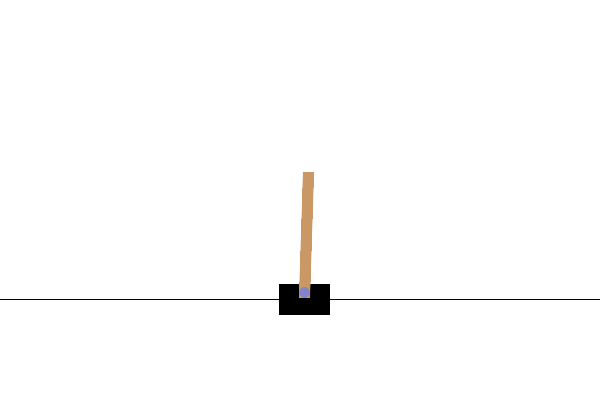

In [ ]:
import gymnasium as gym
import numpy as np
import imageio.v2 as imageio

# 1. Create a new instance of the CartPole environment with 'rgb_array' render mode
# This mode allows us to capture individual frames
gif_env = gym.make("CartPole-v1", render_mode="rgb_array")

# List to store frames
frames = []

# Reset the environment for a new episode
observation, info = gif_env.reset()
current_state = discretize_state(observation, num_bins, lower_bounds, upper_bounds)
total_episode_reward = 0
terminated = False
truncated = False

print("\n--- Generating GIF of Trained Agent's Performance ---")
for timestep in range(200):
    # Capture frame
    frames.append(gif_env.render())

    # Select action with the highest Q-value (greedy policy)
    action = np.argmax(q_table[current_state])

    next_observation, reward, terminated, truncated, info = gif_env.step(action)
    total_episode_reward += reward
    next_state = discretize_state(next_observation, num_bins, lower_bounds, upper_bounds)
    current_state = next_state

    if terminated or truncated:
        break

gif_env.close()

print(f"GIF episode finished with Total Reward: {total_episode_reward}")

# 2. Save the collected frames as a GIF
gif_path = "cartpole_q_learning_demo.gif"
imageio.mimsave(gif_path, frames, fps=30) # fps (frames per second) can be adjusted

print(f"Simulation saved as {gif_path}")

# Optionally, display the GIF in the notebook (requires IPython.display)
from IPython.display import Image
Image(open(gif_path,'rb').read())

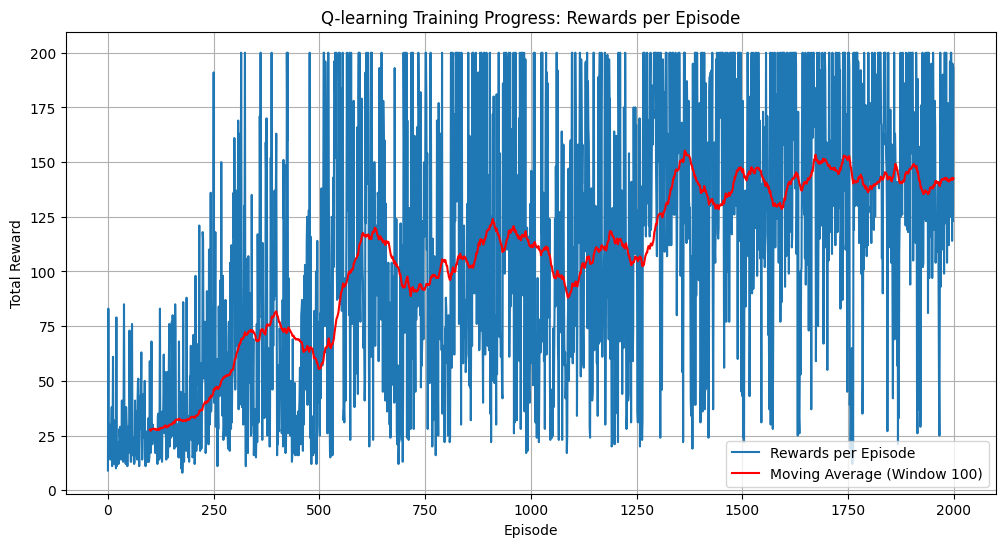

Plots generated showing training rewards.


In [ ]:
import matplotlib.pyplot as plt

# 7. Plot the rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(rewards_per_episode, label='Rewards per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-learning Training Progress: Rewards per Episode')

# 8. Optionally, calculate and plot a moving average of the rewards
window_size = 100 # Define the window size for the moving average
moving_avg = np.convolve(rewards_per_episode, np.ones(window_size)/window_size, mode='valid')
plt.plot(np.arange(len(moving_avg)) + window_size - 1, moving_avg, label=f'Moving Average (Window {window_size})', color='red')

plt.legend()
plt.grid(True)

# 9. Display the plot
plt.show()

print("Plots generated showing training rewards.")